In [1]:
#import req libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.svm import SVR



import os
import warnings
warnings.filterwarnings("ignore")

os.environ["OMP_NUM_THREADS"] = "1"

# Smart Earn

In [2]:
import pandas as pd

# Load the SE customer data
se_data = pd.read_csv('se_customer.csv')
se_data.head(), se_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   membershipid                    1000 non-null   int64  
 1   merchant_id                     1000 non-null   int64  
 2   last_order_date                 1000 non-null   object 
 3   total_points_earned             1000 non-null   int64  
 4   total_order_amount_in_currency  1000 non-null   float64
 5   total_number_of_orders          1000 non-null   int64  
 6   last_points_earned              1000 non-null   int64  
 7   last_order_amount_in_currency   1000 non-null   float64
 8   date_last_activity_earn         1000 non-null   object 
 9   last_activity_earn              1000 non-null   object 
 10  refresheddate                   1000 non-null   object 
 11  Unnamed: 11                     0 non-null      float64
 12  Unnamed: 12                     0 n

(   membershipid  merchant_id   last_order_date  total_points_earned  \
 0    1103245683          153  11/04/2017 21:58                  642   
 1    2028342815          281  09/05/2014 23:07                  539   
 2    2050937124         1122  08/02/2017 16:17                  161   
 3    2112182725          651  24/07/2016 11:40                  116   
 4    5016618831          651  02/10/2021 09:10                   79   
 
    total_order_amount_in_currency  total_number_of_orders  last_points_earned  \
 0                          546.75                       1                 642   
 1                          450.51                       1                 539   
 2                           48.00                       1                 161   
 3                          139.70                       4                  17   
 4                          165.83                       4                  46   
 
    last_order_amount_in_currency date_last_activity_earn last_activity_

In [3]:
columns_to_drop = ['Unnamed: 11', 'Unnamed: 12','Unnamed: 13']
se_data = se_data.drop(columns=columns_to_drop)

In [4]:
# Selecting relevant columns for CLV calculation and feature engineering
se_columns = se_data[['merchant_id', 'membershipid', 'total_order_amount_in_currency', 'total_number_of_orders', 'last_order_date']]

# Convert 'last_order_date' to datetime for potential time-based features
se_columns['last_order_date'] = pd.to_datetime(se_columns['last_order_date'], errors='coerce')

# Sort the DataFrame by 'merchant_id' in ascending order
se_columns = se_columns.sort_values(by='merchant_id', ascending=True)

print(se_columns.head())


     merchant_id  membershipid  total_order_amount_in_currency  \
697           39    5068048240                           33.08   
672           39    5068048240                           33.08   
423           39    5068048240                           33.08   
215           39    5068048240                           33.08   
327           39    5068048240                           33.08   

     total_number_of_orders last_order_date  
697                       1             NaT  
672                       1             NaT  
423                       1             NaT  
215                       1             NaT  
327                       1             NaT  


# Smart Link

In [5]:

# Load the next dataset, SL customer data
sl_data = pd.read_csv('sl_customer.csv')

sl_data.head(), sl_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   merchant_id                      1000 non-null   int64  
 1   consumer_id                      1000 non-null   int64  
 2   consumer_status                  1000 non-null   object 
 3   partner_identifier_for_consumer  279 non-null    object 
 4   consumer_modified_date           1000 non-null   object 
 5   consumer_member_token            1000 non-null   object 
 6   account_id                       1000 non-null   int64  
 7   account_status                   1000 non-null   object 
 8   account_modified_date            1000 non-null   object 
 9   partner_identifier_for_account   151 non-null    object 
 10  offer_link_id                    1000 non-null   int64  
 11  consumer_transacion_id           1000 non-null   int64  
 12  offer_link_status    

(   merchant_id         consumer_id consumer_status  \
 0          193    1906381155455937          Active   
 1          193   22769394246314562          Active   
 2          193   23038391143094108          Active   
 3          193  262263791409639188         Deleted   
 4          153  293123841248915078          Active   
 
     partner_identifier_for_consumer      consumer_modified_date  \
 0  c0a8f2d30002b1d44c265c2a351d4000  2021-12-26 00:00:00.000000   
 1                            234742  2023-08-19 00:00:00.000000   
 2                             68143  2023-09-07 00:00:00.000000   
 3                               NaN  2022-09-05 00:00:00.000000   
 4                               NaN  2022-05-11 00:00:00.000000   
 
                     consumer_member_token          account_id account_status  \
 0  5_d61db94e-7b02-46ae-b509-61b12b0cc6ff    1921381155455902         Active   
 1  5_19554681-d6c5-4580-8158-b7543040e884   20088394246439967         Active   
 2  1_a76f62e2-

In [6]:
# Selecting relevant columns for CLV calculation and feature engineering
sl_columns = sl_data[['merchant_id','consumer_id', 'transaction_amount', 'transaction_date']]

# Convert transaction_date to datetime for potential time-based features
sl_columns['transaction_date'] = pd.to_datetime(sl_columns['transaction_date'], errors='coerce')

# Sort the DataFrame by 'merchant_id' in ascending order
sl_columns = sl_columns.sort_values(by='merchant_id', ascending=True)

sl_columns.head()


,merchant_id,consumer_id,transaction_amount,transaction_date
145,39,7377391144839623,27.68,2023-08-30
431,39,182103741884176354,156.16,2021-05-20
154,39,26007372888286890,69.23,2022-04-11
155,39,323843761664956003,55.00,2022-01-29
157,39,113553841995284618,6.36,2022-10-20


In [7]:
if 'merchant_id' in sl_columns.columns:
    sl_columns = sl_columns.drop(columns=['merchant_id'])
else:
    print("'merchant_id' not found in DataFrame.")

In [8]:
sl_columns

,consumer_id,transaction_amount,transaction_date
145,7377391144839623,27.68,2023-08-30
431,182103741884176354,156.16,2021-05-20
154,26007372888286890,69.23,2022-04-11
155,323843761664956003,55.00,2022-01-29
157,113553841995284618,6.36,2022-10-20
...,...,...,...
320,13526367413168600,58.19,2020-09-04
319,31830367417523591,14.84,2020-11-20
792,5855367418843865,68.87,2022-03-14
144,32128367422047186,39.23,2020-07-11


# Smart Redeem Store

In [9]:
# SRS customer data
srs_data = pd.read_csv('srs_customer.csv')

srs_data.head(), srs_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   int64  
 1   membershipid                    1000 non-null   int64  
 2   last_order_date                 1000 non-null   object 
 3   total_order_amount_in_points    1000 non-null   float64
 4   total_order_amount_in_currency  1000 non-null   float64
 5   last_order_value_in_points      1000 non-null   float64
 6   last_order_value_in_currency    1000 non-null   float64
 7   total_number_of_orders          1000 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


(   merchant_id  membershipid             last_order_date  \
 0          153    1143419335  2021-09-30 19:41:56.000000   
 1         1122    1022135051  2022-11-26 20:19:33.000000   
 2          193    2072966032  2022-12-31 17:56:58.000000   
 3          153    2010642615  2022-03-31 19:35:59.000000   
 4          153    5099625391  2022-10-19 09:33:08.000000   
 
    total_order_amount_in_points  total_order_amount_in_currency  \
 0                       36490.0                       72.980000   
 1                      237230.0                      615.040741   
 2                       21564.0                       48.986000   
 3                       58600.0                      158.220000   
 4                       82436.0                      260.589000   
 
    last_order_value_in_points  last_order_value_in_currency  \
 0                      5215.0                     10.430000   
 1                     19799.0                     51.330741   
 2                     10782.0

In [10]:
# Selecting relevant columns for CLV calculation and feature engineering
srs_columns = srs_data[['merchant_id','membershipid', 'total_order_amount_in_currency', 'total_number_of_orders', 'last_order_date','last_order_value_in_currency','total_order_amount_in_points','last_order_value_in_points']]

# Convert last_order_date to datetime for potential time-based features
srs_columns['last_order_date'] = pd.to_datetime(srs_columns['last_order_date'], errors='coerce')

# Sort the DataFrame by 'merchant_id' in ascending order
srs_columns = srs_columns.sort_values(by='merchant_id', ascending=True)

srs_columns.head()


,merchant_id,membershipid,total_order_amount_in_currency,total_number_of_orders,last_order_date,last_order_value_in_currency,total_order_amount_in_points,last_order_value_in_points
444,39,1556609142,82.3270,1,2022-11-20 23:37:11,63.3430,32188.0,18098.0
788,39,1180512324,28.4830,1,2022-12-26 22:52:20,14.2415,8138.0,4069.0
790,39,1142988566,42.1880,1,2021-03-12 22:13:03,10.8000,21094.0,5400.0
443,39,1130099013,26.9784,1,2020-12-27 15:19:56,13.4892,15896.0,7948.0
442,39,2013254831,49.6580,1,2022-11-10 21:44:33,24.8290,17576.0,8788.0


In [11]:
if 'merchant_id' in srs_columns.columns:
    srs_columns = srs_columns.drop(columns=['merchant_id'])
else:
    print("'merchant_id' not found in DataFrame.")

# Smart Pay

In [12]:
# Load the next dataset, SP customer data
sp_data = pd.read_csv('sp_customer.csv')

sp_data.head(), sp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   int64  
 1   member_id                       1000 non-null   int64  
 2   member_external_id              1000 non-null   int64  
 3   member_programme_id             1000 non-null   int64  
 4   member_tier                     1000 non-null   object 
 5   member_created_at               1000 non-null   object 
 6   member_updated_at               1000 non-null   object 
 7   order_id                        1000 non-null   int64  
 8   order_type                      1000 non-null   object 
 9   order_changed                   1000 non-null   object 
 10  order_item_status               1000 non-null   object 
 11  order_item_sku                  1000 non-null   object 
 12  order_item_title                100

(   merchant_id  member_id  member_external_id  member_programme_id  \
 0          153       2375           504647953                 1737   
 1         1122       4371           235534386                 1737   
 2          193       6670           400331912                 1737   
 3          153       1637           655430285                 1737   
 4          153       2442           731432225                 1737   
 
   member_tier           member_created_at           member_updated_at  \
 0    SKYWARDS  2024-02-10 07:26:35.000000  2024-02-10 07:26:35.000000   
 1    SKYWARDS  2024-02-27 15:33:23.000000  2024-02-27 15:33:23.000000   
 2    SKYWARDS  2024-03-26 03:13:40.000000  2024-03-26 03:13:40.000000   
 3      SILVER  2024-02-09 16:18:09.000000  2024-02-09 16:18:09.000000   
 4    SKYWARDS  2024-02-10 09:32:26.000000  2024-02-10 09:32:26.000000   
 
    order_id        order_type               order_changed  ...  \
 0      1661  voucher_products  2024-02-10 07:27:51.000000 

In [13]:
# Selecting relevant columns for CLV calculation and feature engineering
sp_columns = sp_data[['merchant_id','member_id', 'order_item_client_sell_price', 'member_created_at']]

# Convert member_created_at to datetime for potential time-based features
sp_columns['member_created_at'] = pd.to_datetime(sp_columns['member_created_at'], errors='coerce')

# Sort the DataFrame by 'merchant_id' in ascending order
sp_columns = sp_columns.sort_values(by='merchant_id', ascending=True)

sp_columns.head()


,merchant_id,member_id,order_item_client_sell_price,member_created_at
444,39,2238,21.29,2024-02-10 02:48:40
788,39,1946,25.00,2024-02-09 21:10:08
790,39,1835,56.58,2024-02-09 19:43:49
443,39,402,100.00,2024-02-08 22:40:15
442,39,3831,7.36,2024-02-20 09:48:44


In [14]:
if 'merchant_id' in sp_columns.columns:
    sp_columns = sp_columns.drop(columns=['merchant_id'])
else:
    print("'merchant_id' not found in DataFrame.")
sp_columns

,member_id,order_item_client_sell_price,member_created_at
444,2238,21.29,2024-02-10 02:48:40
788,1946,25.00,2024-02-09 21:10:08
790,1835,56.58,2024-02-09 19:43:49
443,402,100.00,2024-02-08 22:40:15
442,3831,7.36,2024-02-20 09:48:44
...,...,...,...
347,1085,44.20,2024-02-09 12:28:24
413,2855,121.21,2024-02-11 15:02:26
345,2697,250.00,2024-02-11 02:52:20
60,2479,30.00,2024-02-10 10:59:06


## 360 Customer CLV View

In [15]:
df = pd.concat([se_columns, sl_columns, srs_columns, sp_columns], axis=1)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 697 to 40
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   merchant_id                     1000 non-null   int64         
 1   membershipid                    1000 non-null   int64         
 2   total_order_amount_in_currency  1000 non-null   float64       
 3   total_number_of_orders          1000 non-null   int64         
 4   last_order_date                 250 non-null    datetime64[ns]
 5   consumer_id                     1000 non-null   int64         
 6   transaction_amount              996 non-null    float64       
 7   transaction_date                996 non-null    datetime64[ns]
 8   membershipid                    1000 non-null   int64         
 9   total_order_amount_in_currency  1000 non-null   float64       
 10  total_number_of_orders          1000 non-null   int64         
 11  last_orde

In [16]:
df

,merchant_id,membershipid,total_order_amount_in_currency,total_number_of_orders,last_order_date,consumer_id,transaction_amount,transaction_date,membershipid,total_order_amount_in_currency,total_number_of_orders,last_order_date,last_order_value_in_currency,total_order_amount_in_points,last_order_value_in_points,member_id,order_item_client_sell_price,member_created_at
697,39,5068048240,33.08,1,NaT,7913380679934206,89.81,2021-11-07,4496022483,6.2046,1,2021-08-06 20:23:16,6.2046,3576.0,3576.0,5453,20.00,2024-03-11 15:17:00
672,39,5068048240,33.08,1,NaT,3227037619669465,69.99,2021-11-11,4400921382,174.8196,1,2022-05-01 12:47:15,77.2929,64748.0,32409.0,716,10.61,2024-02-09 11:37:47
423,39,5068048240,33.08,1,NaT,133453811651556177,20.27,2023-04-29,1225798404,37.6600,1,2022-12-31 16:06:17,18.8300,17332.0,8666.0,1752,8.84,2024-02-09 18:16:18
215,39,5068048240,33.08,1,NaT,31564391169403226,47.92,2023-06-29,2068773021,411.3270,8,2022-12-31 08:19:27,6.9300,153315.0,5266.0,3618,38.52,2024-02-17 10:06:07
327,39,5068048240,33.08,1,NaT,112743681472710108,27.41,2021-01-07,1264323066,14.5180,2,2022-12-29 13:27:37,7.2590,10720.0,5360.0,4965,1036.00,2024-03-06 09:59:12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,1122,2072771653,65.00,1,NaT,306643751652879908,44.70,2021-11-09,1556609142,82.3270,1,2022-11-20 23:37:11,63.3430,32188.0,18098.0,2238,21.29,2024-02-10 02:48:40
162,1122,1426869775,58.33,1,NaT,27845367413759923,10.68,2020-09-01,1111153771,26.6220,1,2021-10-28 17:04:21,40.6323,17030.0,19323.0,6964,520.00,2024-03-29 22:46:59
159,1122,2050937124,48.00,1,2017-08-02 16:17:00,16933370992318433,50.18,2020-06-17,2065137081,64.9782,1,2021-05-01 12:19:32,21.4785,24066.0,12214.0,5580,7.90,2024-03-12 23:00:20
436,1122,2088019845,103.34,1,NaT,19383377599174102,32.46,2021-11-03,2044092023,231.1925,1,2023-03-27 21:37:37,165.2490,81483.0,54928.0,7310,114.52,2024-03-31 22:05:51


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 697 to 40
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   merchant_id                     1000 non-null   int64         
 1   membershipid                    1000 non-null   int64         
 2   total_order_amount_in_currency  1000 non-null   float64       
 3   total_number_of_orders          1000 non-null   int64         
 4   last_order_date                 250 non-null    datetime64[ns]
 5   consumer_id                     1000 non-null   int64         
 6   transaction_amount              996 non-null    float64       
 7   transaction_date                996 non-null    datetime64[ns]
 8   membershipid                    1000 non-null   int64         
 9   total_order_amount_in_currency  1000 non-null   float64       
 10  total_number_of_orders          1000 non-null   int64         
 11  last_orde

In [18]:
df.to_csv('customer_360_data.csv', index=False)

In [19]:
# Drop rows with missing transaction_amount or transaction_date
df.dropna(subset=['transaction_amount', 'transaction_date'], inplace=True)

In [20]:
# Feature Engineering
total_revenue_per_customer = df.groupby('consumer_id')['transaction_amount'].sum().reset_index(name='total_revenue')
average_order_value = df.groupby('consumer_id').apply(lambda x: x['transaction_amount'].mean()).reset_index(name='average_order_value')
purchase_frequency = df.groupby('consumer_id').size().reset_index(name='purchase_frequency')
current_date = df['transaction_date'].max()
df['recency'] = (current_date - df['transaction_date']).dt.days
recency = df.groupby('consumer_id')['recency'].min().reset_index()

# Merge features
features_df = total_revenue_per_customer.merge(average_order_value, on='consumer_id')
features_df = features_df.merge(purchase_frequency, on='consumer_id')
features_df = features_df.merge(recency, on='consumer_id')

In [21]:
# Define decay rate (lambda) and calculate CLV using a time decay model
lambda_decay = 0.001
df['decay_factor'] = np.exp(-lambda_decay * df['recency'])
df['adjusted_transaction_value'] = df['transaction_amount'] * df['decay_factor']
clv = df.groupby('consumer_id')['adjusted_transaction_value'].sum().reset_index(name='clv')
final_features_clv = features_df.merge(clv, on='consumer_id')



In [22]:
from sklearn.cluster import KMeans
# Clustering customers into four groups
X = final_features_clv[['clv']].values
kmeans = KMeans(n_clusters=4, random_state=0)
final_features_clv['clv_group'] = kmeans.fit_predict(X)

# Evaluate the clustering
cluster_summary = final_features_clv.groupby('clv_group')['clv'].agg(['mean', 'count']).reset_index()

print(final_features_clv.head())
print(cluster_summary)

       consumer_id  total_revenue  average_order_value  purchase_frequency  \
0  109838482944296         101.51               101.51                   1   
1  150391138023305         216.06               216.06                   1   
2  180387561577837          17.20                17.20                   1   
3  244367423297961          50.93                50.93                   1   
4  274936871844726          87.96                87.96                   1   

   recency         clv  clv_group  
0      110   90.936123          3  
1      320  156.891761          3  
2      502   10.411484          0  
3     1221   15.021044          0  
4     1355   22.689044          0  
   clv_group         mean  count
0          0    17.477297    759
1          1  1129.452910      6
2          2   323.506336     27
3          3   100.867331    113


# Building Models and Evaluating

compare their predictions with the actual values on the test set. We'll train each model using the full training dataset, make predictions on the test set, and then calculate the RMSE for each model to see how they perform on unseen data.

In [23]:
# Prepare the data
X = final_features_clv[['total_revenue', 'average_order_value', 'purchase_frequency', 'recency']]
y = final_features_clv['clv']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Define models
models = {
    "XGBoost": XGBRegressor(objective='reg:squarederror'),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

In [25]:
# Cross-validate models
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
    rmse_scores = np.sqrt(-scores)
    cv_results[name] = rmse_scores.mean()

# Print initial cross-validation results
print("Initial CV Results (RMSE):")
for name, score in cv_results.items():
    print(f"{name}: {score:.2f}")

Initial CV Results (RMSE):
XGBoost: 22.71
Random Forest: 28.83
Gradient Boosting: 27.46
SVR: 93.08


In [26]:
# Hyperparameter grids
param_grids = {
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    "Random Forest": {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 10],
        'min_samples_leaf': [1, 4]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    "SVR": {
        'C': [1, 10, 100],
        'gamma': ['scale', 'auto']
    }
}

# Tune hyperparameters
best_estimators = {}
for name, grid in param_grids.items():
    grid_search = GridSearchCV(models[name], grid, cv=10, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)
    best_estimators[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")


Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best parameters for SVR: {'C': 100, 'gamma': 'scale'}


In [27]:
# Evaluate models with testing set
results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = (rmse, r2, mae)

# Print evaluation metrics
for name, metrics in results.items():
    print(f"{name} - Test RMSE: {metrics[0]:.2f}, R2: {metrics[1]:.2f}, MAE: {metrics[2]:.2f}")

XGBoost - Test RMSE: 30.69, R2: 0.93, MAE: 4.77
Random Forest - Test RMSE: 49.62, R2: 0.83, MAE: 7.53
Gradient Boosting - Test RMSE: 30.18, R2: 0.94, MAE: 5.34
SVR - Test RMSE: 63.24, R2: 0.72, MAE: 8.25


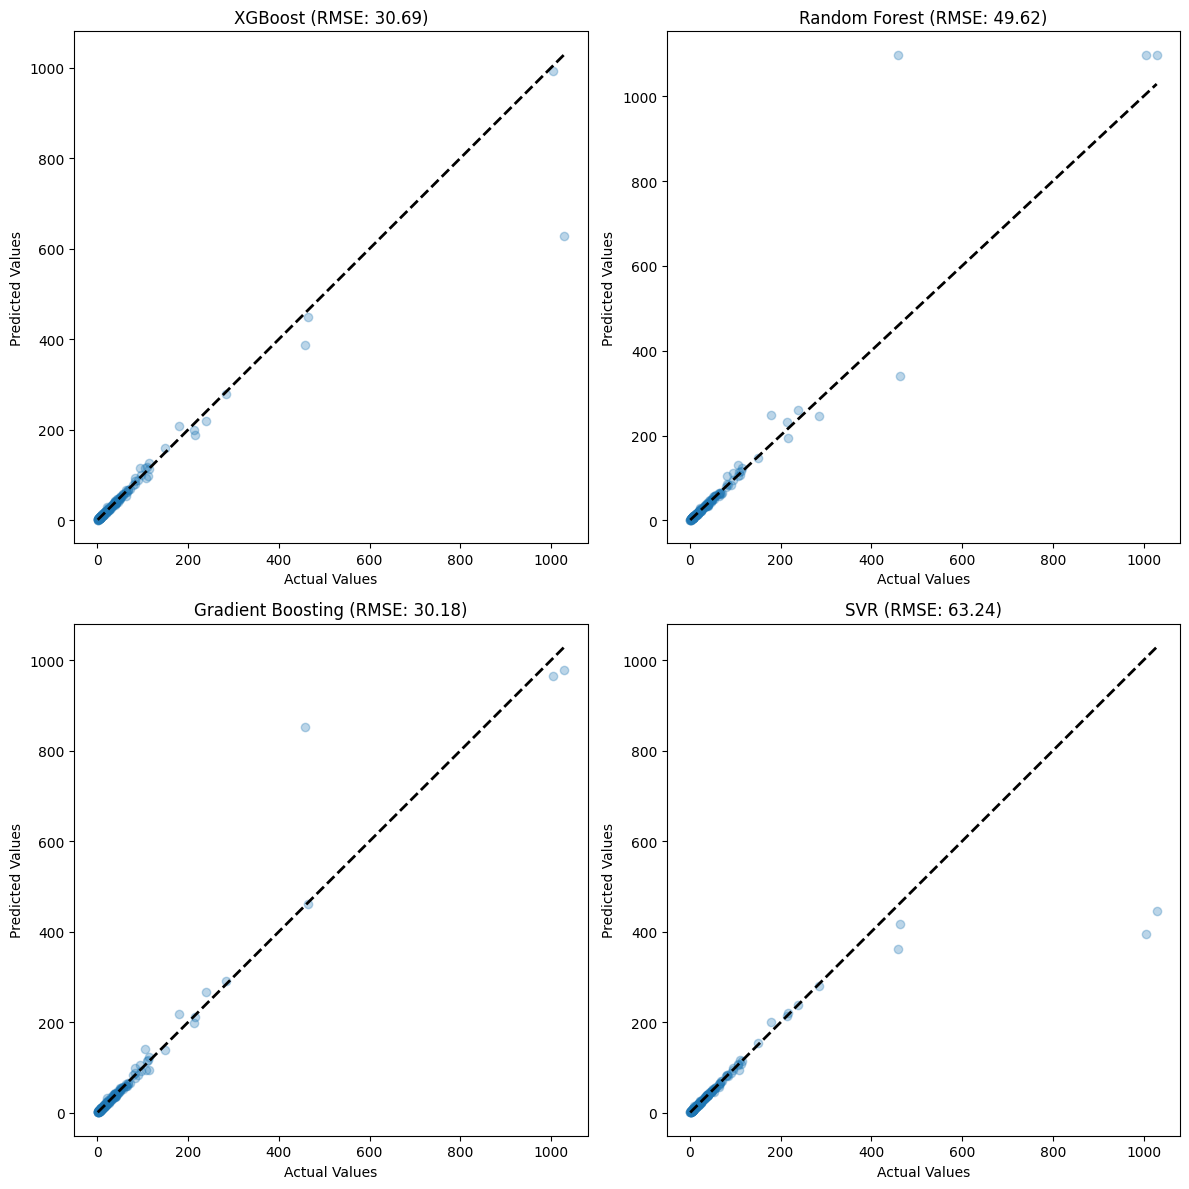

In [28]:
# Visualization of actual vs predicted values for each model
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
for idx, (name, model) in enumerate(best_estimators.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax.set_title(f'{name} (RMSE: {results[name][0]:.2f})')
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()








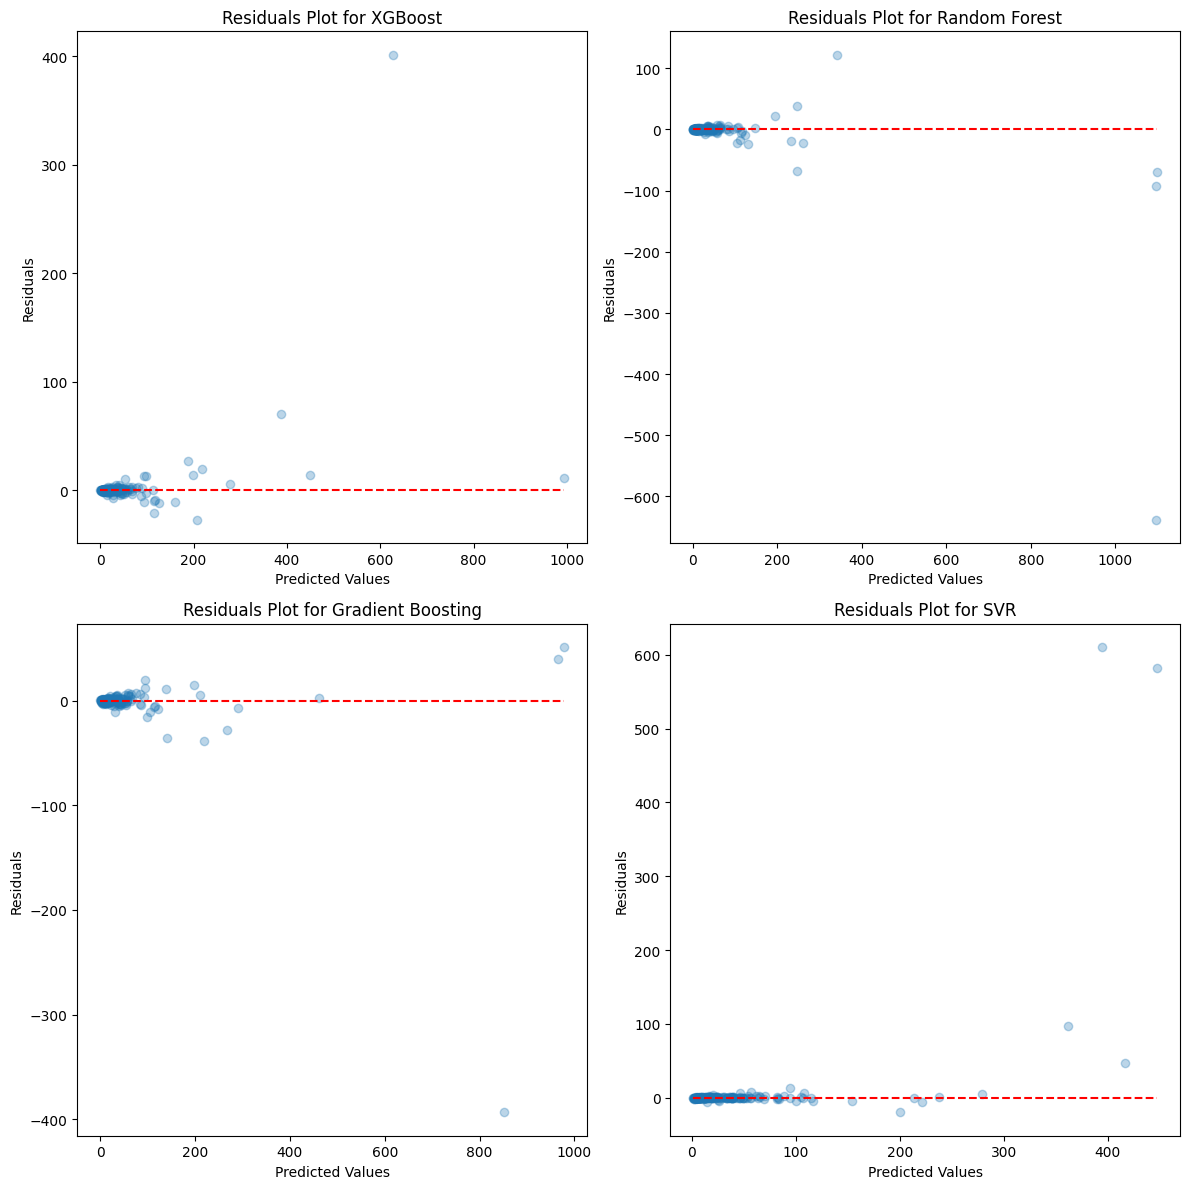

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(best_estimators.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3)
    ax.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), colors='red', linestyles='--')
    ax.set_title(f'Residuals Plot for {name}')
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()